In [10]:
pip install pyreadstat --user

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import pyreadstat
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

# 1. Load the SPSS (.sav) Dataset
# Replace with the exact path to your .sav file
file_path = r"C:\Users\Taiye Fagbolade\Downloads\learning folder\QCHAT_dataset2 mendeley.sav"

try:
    # pd.read_spss requires the 'pyreadstat' library we just installed
    df = pd.read_spss(file_path)
    
    print(f"✅ Dataset Successfully Loaded: {df.shape[0]} Toddlers, {df.shape[1]} Features")
    print("\nOriginal Columns:", df.columns.tolist())
    
    # View the first 5 rows to see what the data looks like
    display(df.head())
    
except Exception as e:
    print(f"❌ Error loading file: {e}")

✅ Dataset Successfully Loaded: 252 Toddlers, 36 Features

Original Columns: ['child_id', 'age', 'sex', 'group', 'preterm', 'birthweight', 'siblings_yesno', 'siblings_number', 'mothers_education', 'sibling_withASD', 'Sum_QCHAT', 'qchat1recode', 'qchat2recode', 'qchat3recode', 'qchat4recode', 'qchat5recode', 'qchat6recode', 'qchat7recode', 'qchat8recode', 'qchat9recode', 'qchat10recode', 'qchat11recode', 'qchat12recode', 'qchat13recode', 'qchat14recode', 'qchat15recode', 'qchat16recode', 'qchat17recode', 'qchat18recode', 'qchat19recode', 'qchat20recode', 'qchat21recode', 'qchat22recode', 'qchat23recode', 'qchat24recode', 'qchat25recode']


,child_id,age,sex,group,preterm,birthweight,siblings_yesno,siblings_number,mothers_education,sibling_withASD,...,qchat16recode,qchat17recode,qchat18recode,qchat19recode,qchat20recode,qchat21recode,qchat22recode,qchat23recode,qchat24recode,qchat25recode
0,220,18.0,Male,ASD,yes,1500.0,no,0.0,highschool,no,...,kilka razy/tydzień,b.niezwykłe,kilka razy/tydzień,kilka razy/tydzień,nigdy,zawsze,kilka minut,nigdy,nigdy,nigdy
1,FS/1642,18.0,Male,ASD,yes,1700.0,no,0.0,higher,no,...,nigdy,b.typowe,nigdy,kilka razy/dzień,nigdy,zazwyczaj,kilka minut,kilka razy/tydzień,nigdy,kilka razy/tydzień
2,340,18.0,Male,ASD,yes,1820.0,no,0.0,higher,no,...,nigdy,całkiem typowe,nigdy,mniej niż raz/tydzień,wiele razy/dzień,czasami,pół godziny,kilka razy/dzień,nigdy,nigdy
3,FS/2571,18.0,Male,ASD,yes,1820.0,no,0.0,higher,no,...,kilka razy/dzień,b.typowe,nigdy,kilka razy/tydzień,kilka razy/tydzień,czasami,kilka minut,kilka razy/tydzień,rzadko,mniej niż raz/tydzień
4,236,18.0,Male,ASD,yes,2360.0,yes,1.0,higher,yes,...,nigdy,b.typowe,mniej niż raz/tydzień,mniej niż raz/tydzień,kilka razy/dzień,zawsze,kilka minut,nigdy,nigdy,kilka razy/tydzień


In [12]:

print("--- PHASE 1: BUILDING THE ORDINAL ASD PREDICTOR ---")

# 1. Load the dataset ignoring the Polish text (Extracting raw numbers only!)
file_path = r"C:\Users\Taiye Fagbolade\Downloads\learning folder\QCHAT_dataset2 mendeley.sav"

# 'apply_value_formats=False' strips away the foreign language and gives us pure 0-4 integers
df, meta = pyreadstat.read_sav(file_path, apply_value_formats=False)

print(f"✅ Raw Numeric Data Successfully Loaded: {df.shape[0]} Toddlers, {df.shape[1]} Features")


--- PHASE 1: BUILDING THE ORDINAL ASD PREDICTOR ---
✅ Raw Numeric Data Successfully Loaded: 252 Toddlers, 36 Features


In [13]:
display (df.head())

,child_id,age,sex,group,preterm,birthweight,siblings_yesno,siblings_number,mothers_education,sibling_withASD,...,qchat16recode,qchat17recode,qchat18recode,qchat19recode,qchat20recode,qchat21recode,qchat22recode,qchat23recode,qchat24recode,qchat25recode
0,220,18.0,1.0,1.0,1.0,1500.0,0.0,0.0,2.0,0.0,...,2.0,3.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
1,FS/1642,18.0,1.0,1.0,1.0,1700.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0
2,340,18.0,1.0,1.0,1.0,1820.0,0.0,0.0,3.0,0.0,...,0.0,1.0,0.0,3.0,4.0,2.0,2.0,3.0,0.0,0.0
3,FS/2571,18.0,1.0,1.0,1.0,1820.0,0.0,0.0,3.0,0.0,...,3.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,1.0,1.0
4,236,18.0,1.0,1.0,1.0,2360.0,1.0,1.0,3.0,1.0,...,0.0,0.0,1.0,3.0,3.0,0.0,0.0,0.0,0.0,2.0


In [14]:
# 2. Identify and Clean the Target Variable ('group')
# In medical datasets, the 'group' column is usually numeric (e.g., 1 for ASD, 2 for Typical Development)
# Let's see what the unique numbers are to be safe
print("\nUnique values in the 'group' column before cleaning:", df['group'].unique())

# Assuming 1 is ASD and anything else (like 0 or 2) is Neurotypical/Control
# (We will map it so ASD = 1 and Control = 0)
# If your data uses different numbers for ASD, we can adjust this, but usually the smallest number or '1' is the condition.
df['Target'] = df['group'].apply(lambda x: 1 if x == 1 else 0)

# 3. Select Features (The 25 Q-CHAT questions + Age + Sex)
feature_cols = [col for col in df.columns if 'qchat' in col.lower()]
feature_cols.extend(['age', 'sex'])

print(f"Features Selected for Training: {len(feature_cols)} columns")


Unique values in the 'group' column before cleaning: [1. 7.]
Features Selected for Training: 28 columns


In [15]:
# Check which group has higher behavioral deficit scores (higher sum = ASD)
print("Average Q-CHAT score for Group 1:", df[df['group'] == 1]['Sum_QCHAT'].mean())
print("Average Q-CHAT score for Group 7:", df[df['group'] == 7]['Sum_QCHAT'].mean())

Average Q-CHAT score for Group 1: 40.72592592592593
Average Q-CHAT score for Group 7: 24.99145299145299


In [16]:
# 4. Prepare X and y
X = df[feature_cols].copy()
y = df['Target']

# 5. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Train the XGBoost Model (Handling any slight class imbalances)
print("\n>>> Training Advanced Ordinal XGBoost Classifier...")
ratio = float(np.sum(y == 0)) / np.sum(y == 1)
asd_model_ordinal = xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=ratio, random_state=42)
asd_model_ordinal.fit(X_train, y_train)

# 7. Evaluate the Model
predictions = asd_model_ordinal.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\n✅ Model Training Complete!")
print(f"Model Accuracy on Test Data: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, predictions))




>>> Training Advanced Ordinal XGBoost Classifier...



✅ Model Training Complete!
Model Accuracy on Test Data: 92.16%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91        24
           1       0.90      0.96      0.93        27

    accuracy                           0.92        51
   macro avg       0.93      0.92      0.92        51
weighted avg       0.92      0.92      0.92        51



🏆 THE TOP 10 MOST IMPORTANT BEHAVIORAL QUESTIONS:
1. qchat6recode
2. qchat2recode
3. qchat5recode
4. qchat4recode
5. qchat10recode
6. qchat15recode
7. qchat25recode
8. qchat11recode
9. qchat1recode
10. qchat17recode


C:\Users\Taiye Fagbolade\AppData\Local\Temp\ipykernel_31028\1904326262.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(12), palette='viridis')


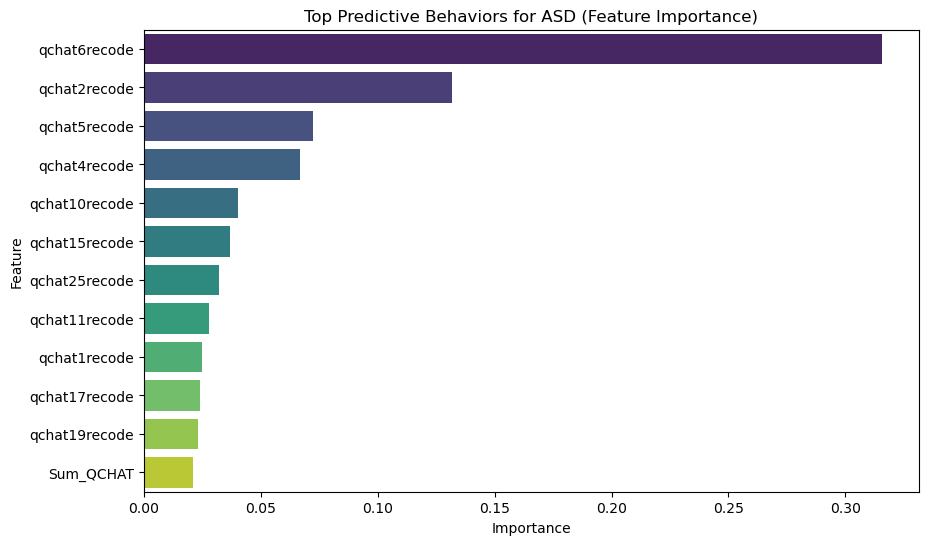

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the importance of each feature from your trained model
importances = asd_model_ordinal.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame to see them clearly
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 3. Print the absolute Top 10 most important Q-CHAT questions (excluding Age and Sex for a moment)
top_qchat_features = df_importance[df_importance['Feature'].str.contains('qchat')].head(10)['Feature'].tolist()

print("🏆 THE TOP 10 MOST IMPORTANT BEHAVIORAL QUESTIONS:")
for i, feature in enumerate(top_qchat_features, 1):
    print(f"{i}. {feature}")

# 4. Let's plot it for your presentation!
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(12), palette='viridis')
plt.title('Top Predictive Behaviors for ASD (Feature Importance)')
plt.show()

--- PHASE 2: BUILDING THE LEAN 'TOP 10' MODEL ---
New Feature Set (12 columns): ['qchat6recode', 'qchat2recode', 'qchat5recode', 'qchat4recode', 'qchat10recode', 'qchat15recode', 'qchat25recode', 'qchat11recode', 'qchat1recode', 'qchat17recode', 'age', 'sex']

Training Lean Ordinal XGBoost Classifier...

✅ Lean Model Training Complete!
Model Accuracy on Test Data: 84.31%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        24
           1       0.85      0.85      0.85        27

    accuracy                           0.84        51
   macro avg       0.84      0.84      0.84        51
weighted avg       0.84      0.84      0.84        51


--- PHASE 2b: CROSS-VALIDATION ---

📊 5-Fold Cross-Validation Results:
Accuracy  : 82.17% (± 5.77%)  |  folds: [np.float64(0.843), np.float64(0.725), np.float64(0.9), np.float64(0.8), np.float64(0.84)]
Precision : 85.03% (± 6.64%)  |  folds: [np.float64(0.913), np.float64(

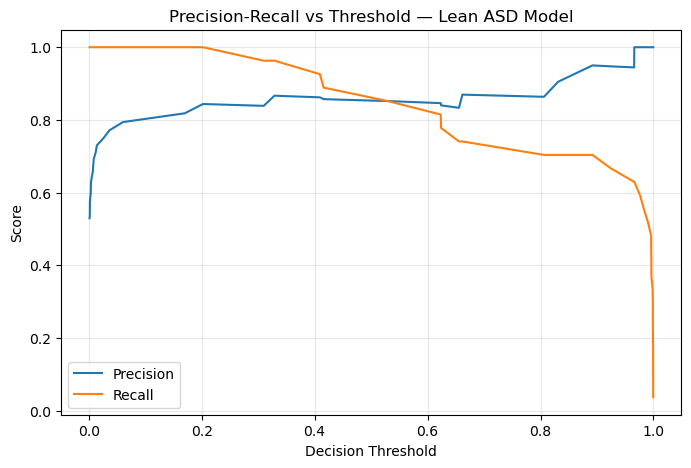


📈 Threshold trade-off:
Threshold 0.50  →  Recall: 85.2%  |  Precision: 85.2%
Threshold 0.45  →  Recall: 85.2%  |  Precision: 85.2%
Threshold 0.40  →  Recall: 92.6%  |  Precision: 86.2%
Threshold 0.35  →  Recall: 92.6%  |  Precision: 86.2%
Threshold 0.30  →  Recall: 96.3%  |  Precision: 83.9%
✅ Saved as 'asd_ordinal_top10_model.pkl'


In [18]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve, recall_score, precision_score
import joblib
import numpy as np
import matplotlib.pyplot as plt

print("--- PHASE 2: BUILDING THE LEAN 'TOP 10' MODEL ---")

# 1. Our new streamlined feature list (Top 10 Questions + Age + Sex)
final_features = top_qchat_features + ['age', 'sex']
print(f"New Feature Set ({len(final_features)} columns): {final_features}")

# 2. Filter our dataset to ONLY these columns
X_lean = df[final_features].copy()
y_lean = df['Target']

# 3. Split the data
X_train_lean, X_test_lean, y_train_lean, y_test_lean = train_test_split(X_lean, y_lean, test_size=0.2, random_state=42, stratify=y_lean)

# 4. Train the LEAN XGBoost Model
print("\nTraining Lean Ordinal XGBoost Classifier...")
ratio = float(np.sum(y_lean == 0)) / np.sum(y_lean == 1)
asd_model_lean = xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=ratio, random_state=42)
asd_model_lean.fit(X_train_lean, y_train_lean)

# 5. Evaluate the new model (original single-split evaluation — keep this)
predictions_lean = asd_model_lean.predict(X_test_lean)
accuracy_lean = accuracy_score(y_test_lean, predictions_lean)

print(f"\n✅ Lean Model Training Complete!")
print(f"Model Accuracy on Test Data: {accuracy_lean * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test_lean, predictions_lean))

# --- 6. NEW: 5-Fold Cross-Validation (more reliable estimate than the single split above) ---
print("\n--- PHASE 2b: CROSS-VALIDATION ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(
    xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=ratio, random_state=42),
    X_lean, y_lean,
    cv=skf,
    scoring=scoring
)

print("\n📊 5-Fold Cross-Validation Results:")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)  |  folds: {[round(s,3) for s in scores]}")

# --- 7. NEW: Threshold tuning on the held-out test split ---
print("\n--- PHASE 2c: THRESHOLD TUNING ---")
probs = asd_model_lean.predict_proba(X_test_lean)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_lean, probs)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold — Lean ASD Model')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Threshold trade-off:")
for t in [0.5, 0.45, 0.4, 0.35, 0.3]:
    preds_t = (probs >= t).astype(int)
    r = recall_score(y_test_lean, preds_t)
    p = precision_score(y_test_lean, preds_t)
    print(f"Threshold {t:.2f}  →  Recall: {r*100:.1f}%  |  Precision: {p*100:.1f}%")

# 8. Save this lean, fast model for our web app!
joblib.dump(asd_model_lean, 'asd_ordinal_top10_model.pkl')
print("✅ Saved as 'asd_ordinal_top10_model.pkl'")